## Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best set of parameters for a machine learning model to improve its performance. These parameters are not learned from data but are set before training.

### Common Hyperparameters to Tune
- **Depth**: Controls how deep a tree can grow (used in tree-based models). Deeper trees can capture more patterns but may overfit.
- **Learning Rate**: Determines how quickly a model learns (used in boosting models). Smaller values are more stable but require more training time.
- **Number of Estimators**: Number of trees in ensemble models. More trees can improve performance but increase computation time.

---

### Import Libraries

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### Load and Split Data
***Here, the digits dataset from scikit-learn is used***

In [2]:
data = load_digits()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Baseline Model (Without Tuning)

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.9722222222222222


---

## 1. Manual Search

Manual tuning is done by trying different values based on intuition.
- You manually try different values based on experience.
- Useful for small problems or quick experiments.

In [4]:
manual_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=4,
    random_state=42
)

manual_model.fit(X_train, y_train)

y_pred = manual_model.predict(X_test)
manual_acc = accuracy_score(y_test, y_pred)

print("Manual Model Accuracy:", manual_acc)

Manual Model Accuracy: 0.9722222222222222


---

## 2. Bayesian Optimization 

Bayesian Optimization selects better hyperparameters based on previous results.
- Builds a probabilistic model to select better hyperparameters.
- Focuses more on promising areas of the search space.
- More efficient than Grid and Random search.

In [5]:
from skopt import BayesSearchCV

param_space = {
    "n_estimators": (50, 300),
    "max_depth": (2, 20),
    "min_samples_split": (2, 10)
}

bayes = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    param_space,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=42
)

bayes.fit(X_train, y_train)

best_model = bayes.best_estimator_

y_pred = best_model.predict(X_test)
bayes_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", bayes.best_params_)
print("Accuracy after Bayesian Optimization:", bayes_acc)

Best Parameters: OrderedDict({'max_depth': 11, 'min_samples_split': 2, 'n_estimators': 300})
Accuracy after Bayesian Optimization: 0.9694444444444444


---

## 3. GridSearchCV
- Tries **all possible combinations** of given hyperparameters.
- Finds the best combination based on model performance.
- **Pros**: Accurate.
- **Cons**: Slow when there are many parameters.

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
grid_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Accuracy after GridSearch:", grid_acc)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy after GridSearch: 0.9805555555555555


---

## 4. Hyperband (using HalvingGridSearchCV)

Hyperband stops poor models early to save time.
- Uses early stopping to quickly discard poor models.
- Saves time by focusing on better configurations.

In [7]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

halving = HalvingGridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    factor=2,
    n_jobs=-1
)

halving.fit(X_train, y_train)

best_model = halving.best_estimator_

y_pred = best_model.predict(X_test)
halving_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", halving.best_params_)
print("Accuracy after Hyperband:", halving_acc)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy after Hyperband: 0.9805555555555555


---

## 5. RandomizedSearchCV
- Tries **random combinations** instead of all.
- You specify how many combinations to test.
- **Pros**: Faster than Grid Search.
- **Cons**: May miss the best combination.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random.fit(X_train, y_train)

best_model = random.best_estimator_

y_pred = best_model.predict(X_test)
random_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", random.best_params_)
print("Accuracy after RandomSearch:", random_acc)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 10}
Accuracy after RandomSearch: 0.9722222222222222


---

## 6. Optuna
- Uses **smart search (Bayesian optimization)** to find best parameters.
- Learns from previous trials to improve results.
- **Pros**: Efficient and powerful.
- **Cons**: Slightly more complex to use.

In [9]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

best_params = study.best_params

optuna_model = RandomForestClassifier(**best_params, random_state=42)
optuna_model.fit(X_train, y_train)

y_pred = optuna_model.predict(X_test)
optuna_acc = accuracy_score(y_test, y_pred)

print("Best Parameters:", best_params)
print("Accuracy after Optuna:", optuna_acc)

[I 2026-05-01 08:52:21,537] A new study created in memory with name: no-name-61c28a97-ef77-4a3a-8a29-e636e62e10fd
[I 2026-05-01 08:52:27,511] Trial 0 finished with value: 0.9171965737514517 and parameters: {'n_estimators': 240, 'max_depth': 4, 'min_samples_split': 8}. Best is trial 0 with value: 0.9171965737514517.
[I 2026-05-01 08:52:35,602] Trial 1 finished with value: 0.9742474835462641 and parameters: {'n_estimators': 221, 'max_depth': 19, 'min_samples_split': 3}. Best is trial 1 with value: 0.9742474835462641.
[I 2026-05-01 08:52:37,189] Trial 2 finished with value: 0.8670949477351917 and parameters: {'n_estimators': 68, 'max_depth': 3, 'min_samples_split': 8}. Best is trial 1 with value: 0.9742474835462641.
[I 2026-05-01 08:52:45,957] Trial 3 finished with value: 0.9672957801006582 and parameters: {'n_estimators': 259, 'max_depth': 9, 'min_samples_split': 10}. Best is trial 1 with value: 0.9742474835462641.
[I 2026-05-01 08:52:52,248] Trial 4 finished with value: 0.96937911343399

Best Parameters: {'n_estimators': 298, 'max_depth': 15, 'min_samples_split': 4}
Accuracy after Optuna: 0.9722222222222222


---

### Final Comparison 

In [10]:
import pandas as pd

results = {
    "Method": [
        "Baseline",
        "GridSearchCV",
        "RandomizedSearchCV",
        "Optuna",
        "Bayesian Optimization",
        "Hyperband",
        "Manual Search"
    ],
    "Accuracy": [
        baseline_acc,
        grid_acc,
        random_acc,
        optuna_acc,
        bayes_acc,
        halving_acc,
        manual_acc
    ]
}

df = pd.DataFrame(results)

# Sort by best performance
df = df.sort_values(by="Accuracy", ascending=False)

df

,Method,Accuracy
1,GridSearchCV,0.980556
5,Hyperband,0.980556
0,Baseline,0.972222
2,RandomizedSearchCV,0.972222
3,Optuna,0.972222
6,Manual Search,0.972222
4,Bayesian Optimization,0.969444


### Visualization

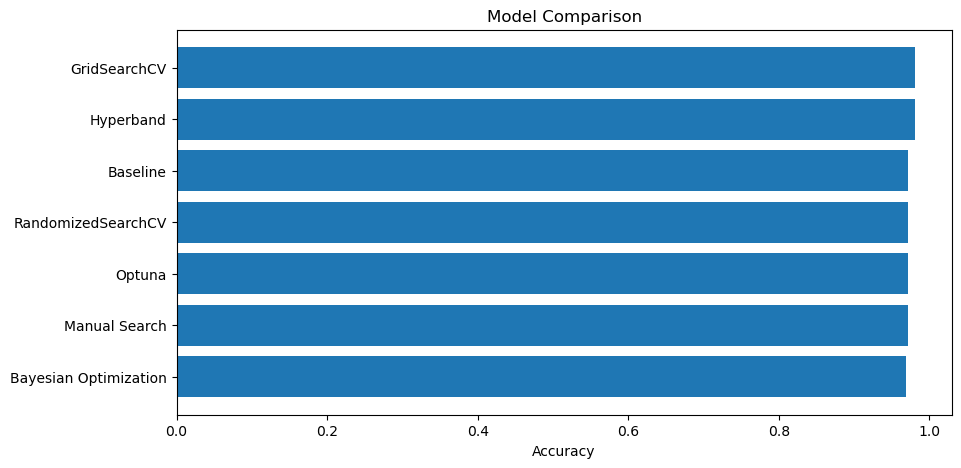

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(df["Method"], df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.gca().invert_yaxis()
plt.show()

### Final Notes
- No single method is always best.
- Use:
  - **GridSearchCV** for small search spaces
  - **RandomizedSearchCV** for faster exploration
  - **Optuna / Bayesian** for smart optimization
  - **Hyperband** when computation is expensive